# 6.2.4 候选模型训练结果对比与最终模型确定

本 Notebook 读取已经完成的 BaselineCNN 与 ResNet18Transfer 验证集结果，在统一数据划分与统一评价指标下比较两种候选模型，并依据验证集 Macro-F1、Top-1 和模型复杂度确定最终模型。

本步骤不读取测试集，也不再训练模型。

In [1]:
# ==========================================
# Cell 2：环境、路径与中文字体
# ==========================================
import os
import json
import shutil
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties
from IPython.display import display

PROJECT_ROOT = Path("/root/autodl-tmp/课设")
RESULTS_ROOT = PROJECT_ROOT / "results" / "06_模型训练与优化"
MODELS_ROOT = PROJECT_ROOT / "models"

BASELINE_RESULT_DIR = RESULTS_ROOT / "6.2.2_BaselineCNN正式训练"
RESNET_RESULT_DIR = RESULTS_ROOT / "6.2.3_ResNet18Transfer分阶段正式训练"
OUTPUT_DIR = RESULTS_ROOT / "6.2.4_候选模型训练结果对比与最终模型确定"
FINAL_MODEL_DIR = MODELS_ROOT / "final_model"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

def find_chinese_font():
    candidates = [
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc",
    ]
    for path in candidates:
        path = Path(path)
        if path.is_file():
            return path
    for root in [Path("/usr/share/fonts"), Path("/usr/local/share/fonts")]:
        if root.exists():
            for path in root.rglob("*"):
                if path.suffix.lower() in {".ttf", ".otf", ".ttc"}:
                    name = path.name.lower()
                    if any(k in name for k in ["notosanscjk", "sourcehan", "wqy", "microhei"]):
                        return path
    return None

CHINESE_FONT_PATH = find_chinese_font()
if CHINESE_FONT_PATH is None:
    raise RuntimeError("未找到中文字体，请先安装 fonts-noto-cjk。")

font_manager.fontManager.addfont(str(CHINESE_FONT_PATH))
CHINESE_FONT_NAME = FontProperties(fname=str(CHINESE_FONT_PATH)).get_name()
plt.rcParams["font.family"] = CHINESE_FONT_NAME
plt.rcParams["font.sans-serif"] = [CHINESE_FONT_NAME]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

print(f"项目目录：{PROJECT_ROOT}")
print(f"输出目录：{OUTPUT_DIR}")
print(f"中文字体：{CHINESE_FONT_NAME}")

项目目录：/root/autodl-tmp/课设
输出目录：/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定
中文字体：Noto Sans CJK JP


In [3]:
# ==========================================
# Cell 3：自动定位候选模型结果与最佳权重
# 增强兼容版本
# ==========================================

from pathlib import Path
import pandas as pd

from IPython.display import display


# --------------------------------------------------
# 1. 检查上一个Cell中的基础路径
# --------------------------------------------------
required_path_variables = [
    "PROJECT_ROOT",
    "RESULTS_ROOT",
    "MODELS_ROOT",
    "BASELINE_RESULT_DIR",
    "RESNET_RESULT_DIR",
    "OUTPUT_DIR",
    "FINAL_MODEL_DIR"
]


missing_path_variables = [
    variable_name
    for variable_name in required_path_variables
    if variable_name not in globals()
]


if missing_path_variables:

    raise NameError(
        "当前内核缺少以下路径变量：\n"
        + "\n".join(
            missing_path_variables
        )
        + "\n\n请先运行6.2.4的Cell 2。"
    )


print(
    "=" * 80
)

print(
    "候选模型结果文件与最佳权重自动定位"
)

print(
    "=" * 80
)


print(
    f"\n项目根目录：\n"
    f"{PROJECT_ROOT}"
)

print(
    f"\nBaselineCNN结果目录：\n"
    f"{BASELINE_RESULT_DIR}"
)

print(
    f"\nResNet18Transfer结果目录：\n"
    f"{RESNET_RESULT_DIR}"
)

print(
    f"\n模型目录：\n"
    f"{MODELS_ROOT}"
)


# --------------------------------------------------
# 2. 通用文件搜索函数
# --------------------------------------------------
def collect_files(
    search_root,
    suffixes=None
):

    search_root = Path(
        search_root
    )


    if not search_root.exists():

        return []


    files = [
        path
        for path in search_root.rglob(
            "*"
        )
        if path.is_file()
    ]


    if suffixes is not None:

        normalized_suffixes = {
            suffix.lower()
            for suffix in suffixes
        }


        files = [
            path
            for path in files
            if path.suffix.lower()
            in normalized_suffixes
        ]


    return files


def find_exact_file(
    search_root,
    exact_names
):

    search_root = Path(
        search_root
    )


    for exact_name in exact_names:

        direct_path = (
            search_root
            / exact_name
        )


        if direct_path.is_file():

            return direct_path


    all_files = collect_files(
        search_root
    )


    for exact_name in exact_names:

        for file_path in all_files:

            if file_path.name == exact_name:

                return file_path


    return None


def find_ranked_file(
    search_root,
    suffixes,
    required_keyword_groups,
    preferred_keywords=None,
    excluded_keywords=None
):

    candidates = collect_files(
        search_root,
        suffixes=suffixes
    )


    preferred_keywords = (
        preferred_keywords
        or []
    )


    excluded_keywords = (
        excluded_keywords
        or []
    )


    ranked_candidates = []


    for file_path in candidates:

        searchable_text = str(
            file_path
        ).lower()


        if any(
            excluded_keyword.lower()
            in searchable_text
            for excluded_keyword
            in excluded_keywords
        ):

            continue


        matched_required_group = False
        required_score = 0


        for keyword_group in required_keyword_groups:

            if all(
                keyword.lower()
                in searchable_text
                for keyword
                in keyword_group
            ):

                matched_required_group = True

                required_score = max(
                    required_score,
                    100
                    + 10
                    * len(
                        keyword_group
                    )
                )


        if not matched_required_group:

            continue


        preferred_score = sum(
            15
            for keyword
            in preferred_keywords
            if keyword.lower()
            in searchable_text
        )


        # 文件名越短、路径越浅，通常越可能是正式结果文件
        simplicity_score = max(
            0,
            30
            - len(
                file_path.name
            )
            / 5
        )


        total_score = (
            required_score
            + preferred_score
            + simplicity_score
        )


        ranked_candidates.append(
            (
                total_score,
                file_path
            )
        )


    if not ranked_candidates:

        return None


    ranked_candidates.sort(
        key=lambda item: (
            item[
                0
            ],
            item[
                1
            ].stat().st_mtime
        ),
        reverse=True
    )


    return ranked_candidates[
        0
    ][
        1
    ]


# --------------------------------------------------
# 3. 定位BaselineCNN结果汇总文件
# --------------------------------------------------
baseline_summary_path = find_exact_file(
    BASELINE_RESULT_DIR,
    exact_names=[
        "14_BaselineCNN正式训练结果汇总.csv",
        "09_BaselineCNN最佳模型验证指标.csv",
        "12_BaselineCNN验证集归一化混淆矩阵.csv"
    ]
)


if baseline_summary_path is None:

    baseline_summary_path = find_ranked_file(
        BASELINE_RESULT_DIR,
        suffixes={
            ".csv"
        },
        required_keyword_groups=[
            [
                "baselinecnn",
                "正式训练结果汇总"
            ],
            [
                "baselinecnn",
                "最佳模型验证指标"
            ],
            [
                "baselinecnn",
                "结果汇总"
            ],
            [
                "baselinecnn",
                "验证指标"
            ]
        ],
        preferred_keywords=[
            "正式训练",
            "结果汇总",
            "最佳模型",
            "验证指标"
        ],
        excluded_keywords=[
            "训练历史",
            "混淆矩阵",
            "各类别",
            "预测明细",
            "配置",
            "dataloader"
        ]
    )


# --------------------------------------------------
# 4. 定位ResNet18Transfer结果汇总文件
# --------------------------------------------------
resnet_summary_path = find_exact_file(
    RESNET_RESULT_DIR,
    exact_names=[
        "20_ResNet18Transfer正式训练结果总览.csv",
        "20_ResNet18Transfer正式训练结果汇总.csv",
        "12_全局最佳模型验证集总体指标.csv",
        "12_ResNet18Transfer全局最佳模型验证集总体指标.csv"
    ]
)


if resnet_summary_path is None:

    resnet_summary_path = find_ranked_file(
        RESNET_RESULT_DIR,
        suffixes={
            ".csv"
        },
        required_keyword_groups=[
            [
                "resnet18transfer",
                "正式训练结果"
            ],
            [
                "全局最佳模型",
                "验证集总体指标"
            ],
            [
                "resnet18transfer",
                "验证指标"
            ],
            [
                "最佳模型",
                "总体指标"
            ]
        ],
        preferred_keywords=[
            "正式训练",
            "结果汇总",
            "结果总览",
            "全局最佳",
            "总体指标"
        ],
        excluded_keywords=[
            "训练历史",
            "混淆矩阵",
            "各类别",
            "预测明细",
            "配置",
            "dataloader"
        ]
    )


# --------------------------------------------------
# 5. 定位BaselineCNN最佳权重
# 不再限制模型文件夹的大小写和命名
# --------------------------------------------------
baseline_checkpoint_path = find_exact_file(
    MODELS_ROOT,
    exact_names=[
        "baseline_cnn_best_model.pth",
        "BaselineCNN_best_model.pth",
        "baselinecnn_best_model.pth",
        "BaselineCNN正式训练最佳模型.pth",
        "baseline_cnn_best.pth"
    ]
)


if baseline_checkpoint_path is None:

    baseline_checkpoint_path = find_ranked_file(
        MODELS_ROOT,
        suffixes={
            ".pth",
            ".pt"
        },
        required_keyword_groups=[
            [
                "baseline",
                "best"
            ],
            [
                "baselinecnn",
                "最佳"
            ],
            [
                "baseline_cnn",
                "最佳"
            ],
            [
                "baselinecnn",
                "best"
            ]
        ],
        preferred_keywords=[
            "best_model",
            "best",
            "最佳模型",
            "正式训练"
        ],
        excluded_keywords=[
            "initial",
            "初始化",
            "last_checkpoint",
            "resnet",
            "phase_a",
            "phase_b",
            "phase_c"
        ]
    )


# --------------------------------------------------
# 6. 定位ResNet18Transfer最佳权重
# --------------------------------------------------
resnet_checkpoint_path = find_exact_file(
    MODELS_ROOT,
    exact_names=[
        "resnet18_transfer_best_model.pth",
        "ResNet18Transfer_best_model.pth",
        "resnet18transfer_best_model.pth"
    ]
)


if resnet_checkpoint_path is None:

    resnet_checkpoint_path = find_ranked_file(
        MODELS_ROOT,
        suffixes={
            ".pth",
            ".pt"
        },
        required_keyword_groups=[
            [
                "resnet18",
                "best"
            ],
            [
                "resnet18transfer",
                "最佳"
            ],
            [
                "resnet18_transfer",
                "最佳"
            ]
        ],
        preferred_keywords=[
            "best_model",
            "best",
            "最佳模型"
        ],
        excluded_keywords=[
            "initial",
            "初始化",
            "last_checkpoint",
            "phase_a",
            "phase_b",
            "phase_c"
        ]
    )


# --------------------------------------------------
# 7. 展示自动定位结果
# --------------------------------------------------
discovered_df = pd.DataFrame([
    {
        "候选模型": "BaselineCNN",
        "结果文件状态": (
            "已找到"
            if baseline_summary_path is not None
            else "未找到"
        ),
        "结果文件": (
            str(
                baseline_summary_path
            )
            if baseline_summary_path is not None
            else ""
        ),
        "最佳权重状态": (
            "已找到"
            if baseline_checkpoint_path is not None
            else "未找到"
        ),
        "最佳权重": (
            str(
                baseline_checkpoint_path
            )
            if baseline_checkpoint_path is not None
            else ""
        )
    },
    {
        "候选模型": "ResNet18Transfer",
        "结果文件状态": (
            "已找到"
            if resnet_summary_path is not None
            else "未找到"
        ),
        "结果文件": (
            str(
                resnet_summary_path
            )
            if resnet_summary_path is not None
            else ""
        ),
        "最佳权重状态": (
            "已找到"
            if resnet_checkpoint_path is not None
            else "未找到"
        ),
        "最佳权重": (
            str(
                resnet_checkpoint_path
            )
            if resnet_checkpoint_path is not None
            else ""
        )
    }
])


print(
    "\n自动定位结果："
)

display(
    discovered_df
)


# --------------------------------------------------
# 8. 缺失时输出目录中的所有候选文件
# --------------------------------------------------
error_messages = []


if baseline_summary_path is None:

    baseline_csv_candidates = collect_files(
        BASELINE_RESULT_DIR,
        suffixes={
            ".csv"
        }
    )


    print(
        "\nBaselineCNN结果目录中的CSV文件："
    )


    for candidate_path in baseline_csv_candidates:

        print(
            candidate_path
        )


    error_messages.append(
        "未找到BaselineCNN结果汇总CSV"
    )


if baseline_checkpoint_path is None:

    baseline_weight_candidates = [
        file_path
        for file_path in collect_files(
            MODELS_ROOT,
            suffixes={
                ".pth",
                ".pt"
            }
        )
        if (
            "baseline"
            in str(
                file_path
            ).lower()
        )
    ]


    print(
        "\n模型目录中可能属于BaselineCNN的权重："
    )


    for candidate_path in baseline_weight_candidates:

        print(
            candidate_path
        )


    error_messages.append(
        "未找到BaselineCNN最佳权重"
    )


if resnet_summary_path is None:

    resnet_csv_candidates = collect_files(
        RESNET_RESULT_DIR,
        suffixes={
            ".csv"
        }
    )


    print(
        "\nResNet18Transfer结果目录中的CSV文件："
    )


    for candidate_path in resnet_csv_candidates:

        print(
            candidate_path
        )


    error_messages.append(
        "未找到ResNet18Transfer结果汇总CSV"
    )


if resnet_checkpoint_path is None:

    resnet_weight_candidates = [
        file_path
        for file_path in collect_files(
            MODELS_ROOT,
            suffixes={
                ".pth",
                ".pt"
            }
        )
        if (
            "resnet18"
            in str(
                file_path
            ).lower()
        )
    ]


    print(
        "\n模型目录中可能属于ResNet18Transfer的权重："
    )


    for candidate_path in resnet_weight_candidates:

        print(
            candidate_path
        )


    error_messages.append(
        "未找到ResNet18Transfer最佳权重"
    )


if error_messages:

    raise FileNotFoundError(
        "仍有以下文件没有定位成功：\n"
        + "\n".join(
            f"- {message}"
            for message in error_messages
        )
        + "\n\n请将本Cell打印出的候选文件列表发给我。"
    )


# --------------------------------------------------
# 9. 最终检查
# --------------------------------------------------
assert baseline_summary_path.is_file()
assert baseline_checkpoint_path.is_file()
assert resnet_summary_path.is_file()
assert resnet_checkpoint_path.is_file()


print(
    "\n候选模型文件定位全部成功。"
)

print(
    f"\nBaselineCNN结果：\n"
    f"{baseline_summary_path}"
)

print(
    f"\nBaselineCNN最佳权重：\n"
    f"{baseline_checkpoint_path}"
)

print(
    f"\nResNet18Transfer结果：\n"
    f"{resnet_summary_path}"
)

print(
    f"\nResNet18Transfer最佳权重：\n"
    f"{resnet_checkpoint_path}"
)

print(
    "\n可以继续运行Cell 4。"
)

候选模型结果文件与最佳权重自动定位

项目根目录：
/root/autodl-tmp/课设

BaselineCNN结果目录：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练

ResNet18Transfer结果目录：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练

模型目录：
/root/autodl-tmp/课设/models

自动定位结果：


,候选模型,结果文件状态,结果文件,最佳权重状态,最佳权重
0,BaselineCNN,已找到,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.2_B...,已找到,/root/autodl-tmp/课设/models/baseline_cnn/Baseli...
1,ResNet18Transfer,已找到,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_R...,已找到,/root/autodl-tmp/课设/models/resnet18_transfer/r...



候选模型文件定位全部成功。

BaselineCNN结果：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练/14_BaselineCNN正式训练结果汇总.csv

BaselineCNN最佳权重：
/root/autodl-tmp/课设/models/baseline_cnn/BaselineCNN_best.pt

ResNet18Transfer结果：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/20_ResNet18Transfer正式训练结果总览.csv

ResNet18Transfer最佳权重：
/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_best_model.pth

可以继续运行Cell 4。


In [6]:
# ==========================================
# Cell 4：读取并统一候选模型验证结果
# 多来源兼容修正版
# ==========================================

import json
import math
import re

from pathlib import Path

import numpy as np
import pandas as pd
import torch

from IPython.display import display


# --------------------------------------------------
# 0. 检查Cell 3的定位结果
# --------------------------------------------------
required_variables = [
    "baseline_summary_path",
    "baseline_checkpoint_path",
    "resnet_summary_path",
    "resnet_checkpoint_path",
    "BASELINE_RESULT_DIR",
    "RESNET_RESULT_DIR",
    "OUTPUT_DIR"
]


missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]


if missing_variables:

    raise NameError(
        "当前缺少以下变量：\n"
        + "\n".join(
            missing_variables
        )
        + "\n\n请先运行修正后的Cell 3。"
    )


# --------------------------------------------------
# 1. 数值清洗函数
# --------------------------------------------------
def parse_numeric_value(
    value
):

    if value is None:

        return np.nan


    if isinstance(
        value,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):

        numeric_value = float(
            value
        )

        if math.isnan(
            numeric_value
        ):

            return np.nan

        return numeric_value


    value_text = str(
        value
    ).strip()


    if value_text == "":

        return np.nan


    if value_text.lower() in {
        "nan",
        "none",
        "null",
        "-"
    }:

        return np.nan


    is_percentage = (
        "%"
        in value_text
    )


    value_text = (
        value_text
        .replace(
            ",",
            ""
        )
        .replace(
            "%",
            ""
        )
        .strip()
    )


    numeric_match = re.search(
        r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?",
        value_text
    )


    if numeric_match is None:

        return np.nan


    numeric_value = float(
        numeric_match.group()
    )


    if is_percentage:

        numeric_value /= 100.0


    return numeric_value


def normalize_metric_value(
    value,
    metric_name
):

    numeric_value = parse_numeric_value(
        value
    )


    if pd.isna(
        numeric_value
    ):

        return np.nan


    ratio_metrics = {
        "验证Top-1",
        "验证Top-3",
        "Macro-Precision",
        "Macro-Recall",
        "Macro-F1",
        "Weighted-F1"
    }


    # 有些文件用94.5表示94.5%，
    # 有些文件用0.945表示94.5%
    if (
        metric_name in ratio_metrics
        and numeric_value > 1.0
        and numeric_value <= 100.0
    ):

        numeric_value /= 100.0


    return float(
        numeric_value
    )


# --------------------------------------------------
# 2. 将CSV转换为可搜索键值字典
# --------------------------------------------------
def dataframe_to_lookup(
    dataframe
):

    lookup = {}


    if dataframe is None or len(
        dataframe
    ) == 0:

        return lookup


    dataframe = dataframe.copy()


    dataframe.columns = [
        str(
            column
        ).strip()
        for column in dataframe.columns
    ]


    # 一行多字段式表格
    for row_index, row in dataframe.iterrows():

        for column_name in dataframe.columns:

            value = row[
                column_name
            ]


            if pd.notna(
                value
            ):

                lookup[
                    str(
                        column_name
                    ).strip()
                ] = value


                lookup[
                    f"{column_name}_{row_index}"
                ] = value


    # 指标—数值纵向表格
    if dataframe.shape[
        1
    ] >= 2:

        possible_key_columns = [
            column_name
            for column_name in dataframe.columns
            if any(
                keyword in str(
                    column_name
                ).lower()
                for keyword in [
                    "指标",
                    "项目",
                    "名称",
                    "metric",
                    "item",
                    "key"
                ]
            )
        ]


        possible_value_columns = [
            column_name
            for column_name in dataframe.columns
            if any(
                keyword in str(
                    column_name
                ).lower()
                for keyword in [
                    "数值",
                    "结果",
                    "value",
                    "score"
                ]
            )
        ]


        if possible_key_columns:

            key_column = possible_key_columns[
                0
            ]

        else:

            key_column = dataframe.columns[
                0
            ]


        if possible_value_columns:

            value_column = possible_value_columns[
                0
            ]

        else:

            value_column = dataframe.columns[
                1
            ]


        for _, row in dataframe.iterrows():

            key_value = row[
                key_column
            ]

            metric_value = row[
                value_column
            ]


            if pd.notna(
                key_value
            ) and pd.notna(
                metric_value
            ):

                lookup[
                    str(
                        key_value
                    ).strip()
                ] = metric_value


    return lookup


# --------------------------------------------------
# 3. 将检查点元数据展开为键值字典
# --------------------------------------------------
def flatten_checkpoint_metadata(
    checkpoint
):

    flattened = {}


    ignored_keys = {
        "model_state_dict",
        "optimizer_state_dict",
        "scheduler_state_dict",
        "scaler_state_dict"
    }


    def recurse(
        current_value,
        prefix=""
    ):

        if isinstance(
            current_value,
            dict
        ):

            for key, value in current_value.items():

                if str(
                    key
                ) in ignored_keys:

                    continue


                new_key = (
                    f"{prefix}.{key}"
                    if prefix
                    else str(
                        key
                    )
                )


                recurse(
                    value,
                    new_key
                )


        elif isinstance(
            current_value,
            (
                list,
                tuple
            )
        ):

            # 类别名称等长列表不需要用于指标解析
            if len(
                current_value
            ) <= 5:

                flattened[
                    prefix
                ] = current_value


        elif isinstance(
            current_value,
            torch.Tensor
        ):

            if current_value.numel() == 1:

                flattened[
                    prefix
                ] = float(
                    current_value.item()
                )


        else:

            flattened[
                prefix
            ] = current_value


    recurse(
        checkpoint
    )


    return flattened


# --------------------------------------------------
# 4. 兼容不同字段名称
# --------------------------------------------------
METRIC_ALIASES = {
    "验证Loss": [
        "验证Loss",
        "验证损失",
        "val_loss",
        "validation_loss",
        "best_val_loss",
        "best_validation_metrics.loss",
        "best_validation_metrics.val_loss",
        "best_global.val_loss"
    ],
    "验证Top-1": [
        "验证Top-1",
        "验证Top1",
        "验证准确率",
        "Top-1",
        "Top1",
        "val_top1",
        "validation_top1",
        "val_accuracy",
        "accuracy",
        "best_val_top1",
        "best_validation_metrics.top1",
        "best_validation_metrics.val_top1",
        "best_global.val_top1"
    ],
    "验证Top-3": [
        "验证Top-3",
        "验证Top3",
        "Top-3",
        "Top3",
        "val_top3",
        "validation_top3",
        "best_val_top3",
        "best_validation_metrics.top3",
        "best_validation_metrics.val_top3",
        "best_global.val_top3"
    ],
    "Macro-Precision": [
        "Macro-Precision",
        "Macro Precision",
        "Macro_Precision",
        "宏平均Precision",
        "macro_precision",
        "val_macro_precision",
        "best_validation_metrics.macro_precision"
    ],
    "Macro-Recall": [
        "Macro-Recall",
        "Macro Recall",
        "Macro_Recall",
        "宏平均Recall",
        "macro_recall",
        "val_macro_recall",
        "best_validation_metrics.macro_recall"
    ],
    "Macro-F1": [
        "Macro-F1",
        "Macro F1",
        "Macro_F1",
        "验证Macro-F1",
        "验证Macro F1",
        "验证Macro_F1",
        "宏平均F1",
        "macro_f1",
        "val_macro_f1",
        "validation_macro_f1",
        "best_val_macro_f1",
        "best_validation_metrics.macro_f1",
        "best_validation_metrics.val_macro_f1",
        "best_global.val_macro_f1"
    ],
    "Weighted-F1": [
        "Weighted-F1",
        "Weighted F1",
        "Weighted_F1",
        "验证Weighted-F1",
        "加权F1",
        "weighted_f1",
        "val_weighted_f1",
        "best_validation_metrics.weighted_f1"
    ],
    "最佳Epoch": [
        "最佳Epoch",
        "最佳轮次",
        "best_epoch",
        "best_global_epoch",
        "epoch",
        "best_global.epoch"
    ],
    "模型总参数": [
        "模型总参数",
        "总参数量",
        "参数量",
        "total_parameters",
        "parameter_count",
        "model_parameters",
        "run_config.total_parameters"
    ]
}


def normalize_key_text(
    key
):

    return (
        str(
            key
        )
        .strip()
        .lower()
        .replace(
            " ",
            ""
        )
        .replace(
            "_",
            ""
        )
        .replace(
            "-",
            ""
        )
        .replace(
            "：",
            ""
        )
        .replace(
            ":",
            ""
        )
    )


def extract_metric(
    lookup_sources,
    metric_name
):

    aliases = METRIC_ALIASES[
        metric_name
    ]


    normalized_aliases = [
        normalize_key_text(
            alias
        )
        for alias in aliases
    ]


    # 第一轮：精确归一化匹配
    for source_name, lookup in lookup_sources:

        for key, value in lookup.items():

            normalized_key = normalize_key_text(
                key
            )


            if normalized_key in normalized_aliases:

                numeric_value = normalize_metric_value(
                    value,
                    metric_name
                )


                if not pd.isna(
                    numeric_value
                ):

                    return (
                        numeric_value,
                        source_name,
                        str(
                            key
                        )
                    )


    # 第二轮：字段名包含别名
    for source_name, lookup in lookup_sources:

        for key, value in lookup.items():

            normalized_key = normalize_key_text(
                key
            )


            if any(
                normalized_alias in normalized_key
                or normalized_key in normalized_alias
                for normalized_alias
                in normalized_aliases
            ):

                numeric_value = normalize_metric_value(
                    value,
                    metric_name
                )


                if not pd.isna(
                    numeric_value
                ):

                    return (
                        numeric_value,
                        source_name,
                        str(
                            key
                        )
                    )


    return (
        np.nan,
        "",
        ""
    )


# --------------------------------------------------
# 5. 安全读取CSV
# --------------------------------------------------
def read_csv_flexible(
    csv_path
):

    csv_path = Path(
        csv_path
    )


    encoding_candidates = [
        "utf-8-sig",
        "utf-8",
        "gb18030",
        "gbk"
    ]


    last_error = None


    for encoding_name in encoding_candidates:

        try:

            return pd.read_csv(
                csv_path,
                encoding=encoding_name
            )


        except Exception as error:

            last_error = error


    raise RuntimeError(
        f"无法读取CSV：\n"
        f"{csv_path}\n"
        f"最后错误：{last_error}"
    )


# --------------------------------------------------
# 6. 自动寻找训练历史作为备用指标来源
# --------------------------------------------------
def find_training_history(
    result_directory,
    model_keyword
):

    candidates = []


    for csv_path in Path(
        result_directory
    ).rglob(
        "*.csv"
    ):

        path_text = str(
            csv_path
        ).lower()


        if (
            "训练历史"
            in csv_path.name
            or "history"
            in path_text
        ):

            if model_keyword.lower() in path_text:

                candidates.append(
                    csv_path
                )


    if not candidates:

        return None


    candidates.sort(
        key=lambda path: path.stat().st_mtime,
        reverse=True
    )


    return candidates[
        0
    ]


def training_history_best_lookup(
    history_path
):

    if history_path is None:

        return {}


    history_df = read_csv_flexible(
        history_path
    )


    possible_macro_columns = [
        column_name
        for column_name in history_df.columns
        if normalize_key_text(
            column_name
        ) in {
            normalize_key_text(
                alias
            )
            for alias in METRIC_ALIASES[
                "Macro-F1"
            ]
        }
    ]


    if not possible_macro_columns:

        possible_macro_columns = [
            column_name
            for column_name in history_df.columns
            if (
                "macro"
                in str(
                    column_name
                ).lower()
                and "f1"
                in str(
                    column_name
                ).lower()
                and (
                    "val"
                    in str(
                        column_name
                    ).lower()
                    or "验证"
                    in str(
                        column_name
                    )
                )
            )
        ]


    if not possible_macro_columns:

        return dataframe_to_lookup(
            history_df
        )


    macro_column = possible_macro_columns[
        0
    ]


    numeric_macro = pd.to_numeric(
        history_df[
            macro_column
        ],
        errors="coerce"
    )


    if numeric_macro.notna().sum() == 0:

        return dataframe_to_lookup(
            history_df
        )


    best_index = numeric_macro.idxmax()


    best_row_df = pd.DataFrame(
        [
            history_df.loc[
                best_index
            ].to_dict()
        ]
    )


    return dataframe_to_lookup(
        best_row_df
    )


# --------------------------------------------------
# 7. 读取单个候选模型全部信息
# --------------------------------------------------
def load_candidate_information(
    model_name,
    summary_path,
    checkpoint_path,
    result_directory,
    history_keyword,
    fallback_parameter_count
):

    summary_df = read_csv_flexible(
        summary_path
    )


    summary_lookup = dataframe_to_lookup(
        summary_df
    )


    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )


    checkpoint_lookup = flatten_checkpoint_metadata(
        checkpoint
    )


    history_path = find_training_history(
        result_directory,
        history_keyword
    )


    history_lookup = training_history_best_lookup(
        history_path
    )


    lookup_sources = [
        (
            "结果汇总CSV",
            summary_lookup
        ),
        (
            "最佳模型检查点",
            checkpoint_lookup
        ),
        (
            "训练历史最佳轮次",
            history_lookup
        )
    ]


    output_record = {
        "候选模型": model_name,
        "结果汇总文件": str(
            summary_path
        ),
        "最佳权重路径": str(
            checkpoint_path
        ),
        "训练历史文件": (
            str(
                history_path
            )
            if history_path is not None
            else ""
        )
    }


    metric_source_records = []


    for metric_name in METRIC_ALIASES:

        metric_value, source_name, source_key = extract_metric(
            lookup_sources,
            metric_name
        )


        output_record[
            metric_name
        ] = metric_value


        metric_source_records.append(
            {
                "候选模型": model_name,
                "统一指标": metric_name,
                "提取结果": metric_value,
                "数据来源": source_name,
                "原始字段": source_key
            }
        )


    if pd.isna(
        output_record[
            "模型总参数"
        ]
    ):

        output_record[
            "模型总参数"
        ] = int(
            fallback_parameter_count
        )


        metric_source_records.append(
            {
                "候选模型": model_name,
                "统一指标": "模型总参数",
                "提取结果": int(
                    fallback_parameter_count
                ),
                "数据来源": "模型结构已知值",
                "原始字段": "fallback_parameter_count"
            }
        )


    output_record[
        "模型总参数"
    ] = int(
        output_record[
            "模型总参数"
        ]
    )


    if not pd.isna(
        output_record[
            "最佳Epoch"
        ]
    ):

        output_record[
            "最佳Epoch"
        ] = int(
            output_record[
                "最佳Epoch"
            ]
        )


    source_df = pd.DataFrame(
        metric_source_records
    )


    return (
        output_record,
        source_df,
        summary_df,
        checkpoint_lookup
    )


# --------------------------------------------------
# 8. 加载BaselineCNN
# --------------------------------------------------
(
    baseline_record,
    baseline_source_df,
    baseline_raw_summary_df,
    baseline_checkpoint_lookup
) = load_candidate_information(
    model_name="BaselineCNN",
    summary_path=baseline_summary_path,
    checkpoint_path=baseline_checkpoint_path,
    result_directory=BASELINE_RESULT_DIR,
    history_keyword="baseline",
    fallback_parameter_count=391946
)


# --------------------------------------------------
# 9. 加载ResNet18Transfer
# --------------------------------------------------
(
    resnet_record,
    resnet_source_df,
    resnet_raw_summary_df,
    resnet_checkpoint_lookup
) = load_candidate_information(
    model_name="ResNet18Transfer",
    summary_path=resnet_summary_path,
    checkpoint_path=resnet_checkpoint_path,
    result_directory=RESNET_RESULT_DIR,
    history_keyword="resnet18",
    fallback_parameter_count=11181642
)


# --------------------------------------------------
# 10. 生成统一候选模型对比表
# --------------------------------------------------
comparison_columns = [
    "候选模型",
    "验证Loss",
    "验证Top-1",
    "验证Top-3",
    "Macro-Precision",
    "Macro-Recall",
    "Macro-F1",
    "Weighted-F1",
    "最佳Epoch",
    "模型总参数",
    "结果汇总文件",
    "训练历史文件",
    "最佳权重路径"
]


comparison_df = pd.DataFrame(
    [
        baseline_record,
        resnet_record
    ]
)


comparison_df = comparison_df[
    comparison_columns
]


metric_source_df = pd.concat(
    [
        baseline_source_df,
        resnet_source_df
    ],
    ignore_index=True
)


print(
    "=" * 80
)

print(
    "候选模型统一验证指标"
)

print(
    "=" * 80
)


display(
    comparison_df
)


print(
    "\n各项指标的数据来源："
)

display(
    metric_source_df
)


# --------------------------------------------------
# 11. 检查关键指标完整性
# --------------------------------------------------
critical_metrics = [
    "验证Top-1",
    "Macro-F1",
    "模型总参数"
]


missing_metric_messages = []


for row_index, row in comparison_df.iterrows():

    for metric_name in critical_metrics:

        if pd.isna(
            row[
                metric_name
            ]
        ):

            missing_metric_messages.append(
                f"{row['候选模型']}："
                f"{metric_name}"
            )


if missing_metric_messages:

    print(
        "\nBaselineCNN原始结果汇总："
    )

    display(
        baseline_raw_summary_df
    )


    print(
        "\nResNet18Transfer原始结果汇总："
    )

    display(
        resnet_raw_summary_df
    )


    raise ValueError(
        "以下关键指标仍未能识别：\n"
        + "\n".join(
            f"- {message}"
            for message in missing_metric_messages
        )
        + "\n\n请把上方显示的原始结果表和指标来源表发给我。"
    )


# --------------------------------------------------
# 12. 保存统一对比表
# --------------------------------------------------
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


comparison_path = (
    OUTPUT_DIR
    / "01_候选模型统一验证指标.csv"
)


metric_source_path = (
    OUTPUT_DIR
    / "02_候选模型指标来源检查.csv"
)


comparison_df.to_csv(
    comparison_path,
    index=False,
    encoding="utf-8-sig"
)


metric_source_df.to_csv(
    metric_source_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n候选模型指标读取成功。"
)

print(
    f"\n统一指标表已保存：\n"
    f"{comparison_path}"
)

print(
    f"\n指标来源表已保存：\n"
    f"{metric_source_path}"
)

print(
    "\n现在可以继续运行Cell 5。"
)

候选模型统一验证指标


,候选模型,验证Loss,验证Top-1,验证Top-3,Macro-Precision,Macro-Recall,Macro-F1,Weighted-F1,最佳Epoch,模型总参数,结果汇总文件,训练历史文件,最佳权重路径
0,BaselineCNN,0.142740,0.952099,0.997037,0.951513,0.950333,0.950705,0.951926,29,391946,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.2_B...,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.2_B...,/root/autodl-tmp/课设/models/baseline_cnn/Baseli...
1,ResNet18Transfer,0.074845,0.983210,0.999753,0.982907,0.982267,0.982560,0.983190,30,11181642,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_R...,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_R...,/root/autodl-tmp/课设/models/resnet18_transfer/r...



各项指标的数据来源：


,候选模型,统一指标,提取结果,数据来源,原始字段
0,BaselineCNN,验证Loss,1.427405e-01,训练历史最佳轮次,验证损失
1,BaselineCNN,验证Top-1,9.520988e-01,结果汇总CSV,最佳验证Top-1准确率
2,BaselineCNN,验证Top-3,9.970371e-01,结果汇总CSV,最佳验证Top-3准确率
3,BaselineCNN,Macro-Precision,9.515127e-01,结果汇总CSV,最佳验证Macro-Precision
4,BaselineCNN,Macro-Recall,9.503333e-01,结果汇总CSV,最佳验证Macro-Recall
5,BaselineCNN,Macro-F1,9.507051e-01,训练历史最佳轮次,验证Macro-F1
6,BaselineCNN,Weighted-F1,9.519261e-01,训练历史最佳轮次,验证Weighted-F1
7,BaselineCNN,最佳Epoch,2.900000e+01,结果汇总CSV,最佳轮次
8,BaselineCNN,模型总参数,3.919460e+05,结果汇总CSV,模型总参数量
9,ResNet18Transfer,验证Loss,7.484549e-02,最佳模型检查点,best_validation_metrics.loss



候选模型指标读取成功。

统一指标表已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定/01_候选模型统一验证指标.csv

指标来源表已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定/02_候选模型指标来源检查.csv

现在可以继续运行Cell 5。


In [7]:
# ==========================================
# Cell 5：依据验证集结果确定最终模型
# 完整性检查与自动排序修正版
# ==========================================

import json

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------
# 1. 检查上一Cell结果
# --------------------------------------------------
if "comparison_df" not in globals():

    raise NameError(
        "当前内核中不存在comparison_df。\n"
        "请先运行修正后的Cell 4。"
    )


required_columns = [
    "候选模型",
    "验证Top-1",
    "Macro-F1",
    "模型总参数",
    "最佳权重路径"
]


missing_columns = [
    column_name
    for column_name in required_columns
    if column_name not in comparison_df.columns
]


if missing_columns:

    raise KeyError(
        "候选模型对比表缺少以下字段：\n"
        + "\n".join(
            missing_columns
        )
    )


ranking_df = comparison_df.copy()


numeric_columns = [
    "验证Loss",
    "验证Top-1",
    "验证Top-3",
    "Macro-Precision",
    "Macro-Recall",
    "Macro-F1",
    "Weighted-F1",
    "最佳Epoch",
    "模型总参数"
]


for column_name in numeric_columns:

    if column_name in ranking_df.columns:

        ranking_df[
            column_name
        ] = pd.to_numeric(
            ranking_df[
                column_name
            ],
            errors="coerce"
        )


print(
    "参与最终模型选择的候选指标："
)

display(
    ranking_df[
        [
            "候选模型",
            "Macro-F1",
            "验证Top-1",
            "验证Top-3",
            "验证Loss",
            "模型总参数",
            "最佳权重路径"
        ]
    ]
)


# --------------------------------------------------
# 2. 关键指标检查
# --------------------------------------------------
critical_columns = [
    "Macro-F1",
    "验证Top-1",
    "模型总参数"
]


missing_records = []


for row_index, row in ranking_df.iterrows():

    for column_name in critical_columns:

        if pd.isna(
            row[
                column_name
            ]
        ):

            missing_records.append(
                {
                    "候选模型": row[
                        "候选模型"
                    ],
                    "缺失指标": column_name
                }
            )


if missing_records:

    missing_df = pd.DataFrame(
        missing_records
    )


    display(
        missing_df
    )


    raise ValueError(
        "候选模型关键指标仍不完整，"
        "请检查修正后Cell 4的指标来源表。"
    )


# --------------------------------------------------
# 3. 指标合理性检查
# --------------------------------------------------
for metric_name in [
    "Macro-F1",
    "验证Top-1"
]:

    invalid_mask = (
        (
            ranking_df[
                metric_name
            ] < 0
        )
        |
        (
            ranking_df[
                metric_name
            ] > 1
        )
    )


    if invalid_mask.any():

        raise ValueError(
            f"{metric_name}存在超出[0, 1]"
            f"范围的数值：\n"
            f"{ranking_df.loc[invalid_mask, ['候选模型', metric_name]]}"
        )


# --------------------------------------------------
# 4. 排序规则
# 第一指标：Macro-F1越高越优
# 第二指标：Top-1越高越优
# 第三指标：参数量越少越优
# --------------------------------------------------
ranked_df = (
    ranking_df
    .sort_values(
        by=[
            "Macro-F1",
            "验证Top-1",
            "模型总参数"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


ranked_df.insert(
    0,
    "综合排名",
    np.arange(
        1,
        len(
            ranked_df
        ) + 1
    )
)


print(
    "\n候选模型排序结果："
)

display(
    ranked_df[
        [
            "综合排名",
            "候选模型",
            "Macro-F1",
            "验证Top-1",
            "验证Top-3",
            "验证Loss",
            "模型总参数"
        ]
    ]
)


# --------------------------------------------------
# 5. 确定最终模型
# --------------------------------------------------
selected_row = ranked_df.iloc[
    0
]


selected_model_name = str(
    selected_row[
        "候选模型"
    ]
)


selected_checkpoint_path = Path(
    selected_row[
        "最佳权重路径"
    ]
)


if not selected_checkpoint_path.is_file():

    raise FileNotFoundError(
        "最终候选模型权重不存在：\n"
        f"{selected_checkpoint_path}"
    )


selection_reason = (
    f"{selected_model_name}在统一验证集上的"
    f"Macro-F1为"
    f"{selected_row['Macro-F1']:.4%}，"
    f"Top-1准确率为"
    f"{selected_row['验证Top-1']:.4%}。"
    f"按照Macro-F1优先、Top-1次优、"
    f"参数量作为同分条件的规则，"
    f"该模型排名第一。"
)


final_selection = {
    "最终模型名称": selected_model_name,
    "最终模型权重": str(
        selected_checkpoint_path
    ),
    "验证Macro-F1": float(
        selected_row[
            "Macro-F1"
        ]
    ),
    "验证Top-1": float(
        selected_row[
            "验证Top-1"
        ]
    ),
    "验证Top-3": (
        float(
            selected_row[
                "验证Top-3"
            ]
        )
        if (
            "验证Top-3"
            in selected_row.index
            and not pd.isna(
                selected_row[
                    "验证Top-3"
                ]
            )
        )
        else None
    ),
    "验证Loss": (
        float(
            selected_row[
                "验证Loss"
            ]
        )
        if (
            "验证Loss"
            in selected_row.index
            and not pd.isna(
                selected_row[
                    "验证Loss"
                ]
            )
        )
        else None
    ),
    "模型总参数": int(
        selected_row[
            "模型总参数"
        ]
    ),
    "选择依据": selection_reason
}


print(
    "\n最终候选模型："
)

print(
    f"模型名称："
    f"{selected_model_name}"
)

print(
    f"验证Macro-F1："
    f"{final_selection['验证Macro-F1']:.4%}"
)

print(
    f"验证Top-1："
    f"{final_selection['验证Top-1']:.4%}"
)

print(
    f"模型总参数："
    f"{final_selection['模型总参数']:,}"
)

print(
    f"模型权重：\n"
    f"{selected_checkpoint_path}"
)

print(
    f"\n选择依据：\n"
    f"{selection_reason}"
)


# --------------------------------------------------
# 6. 保存排序与选择结果
# --------------------------------------------------
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


ranking_output_path = (
    OUTPUT_DIR
    / "03_候选模型验证性能排名.csv"
)


selection_json_path = (
    OUTPUT_DIR
    / "00_最终模型选择结果.json"
)


selection_csv_path = (
    OUTPUT_DIR
    / "04_最终模型选择结果.csv"
)


ranked_df.to_csv(
    ranking_output_path,
    index=False,
    encoding="utf-8-sig"
)


with open(
    selection_json_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_selection,
        file,
        ensure_ascii=False,
        indent=2
    )


pd.DataFrame(
    [
        final_selection
    ]
).to_csv(
    selection_csv_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n最终模型选择结果已保存。"
)

print(
    f"\nJSON：\n"
    f"{selection_json_path}"
)

print(
    f"\nCSV：\n"
    f"{selection_csv_path}"
)

print(
    "\n可以继续运行Cell 6。"
)

参与最终模型选择的候选指标：


,候选模型,Macro-F1,验证Top-1,验证Top-3,验证Loss,模型总参数,最佳权重路径
0,BaselineCNN,0.950705,0.952099,0.997037,0.142740,391946,/root/autodl-tmp/课设/models/baseline_cnn/Baseli...
1,ResNet18Transfer,0.982560,0.983210,0.999753,0.074845,11181642,/root/autodl-tmp/课设/models/resnet18_transfer/r...



候选模型排序结果：


,综合排名,候选模型,Macro-F1,验证Top-1,验证Top-3,验证Loss,模型总参数
0,1,ResNet18Transfer,0.982560,0.983210,0.999753,0.074845,11181642
1,2,BaselineCNN,0.950705,0.952099,0.997037,0.142740,391946



最终候选模型：
模型名称：ResNet18Transfer
验证Macro-F1：98.2560%
验证Top-1：98.3210%
模型总参数：11,181,642
模型权重：
/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_best_model.pth

选择依据：
ResNet18Transfer在统一验证集上的Macro-F1为98.2560%，Top-1准确率为98.3210%。按照Macro-F1优先、Top-1次优、参数量作为同分条件的规则，该模型排名第一。

最终模型选择结果已保存。

JSON：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定/00_最终模型选择结果.json

CSV：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定/04_最终模型选择结果.csv

可以继续运行Cell 6。


采用模型名称字段：候选模型


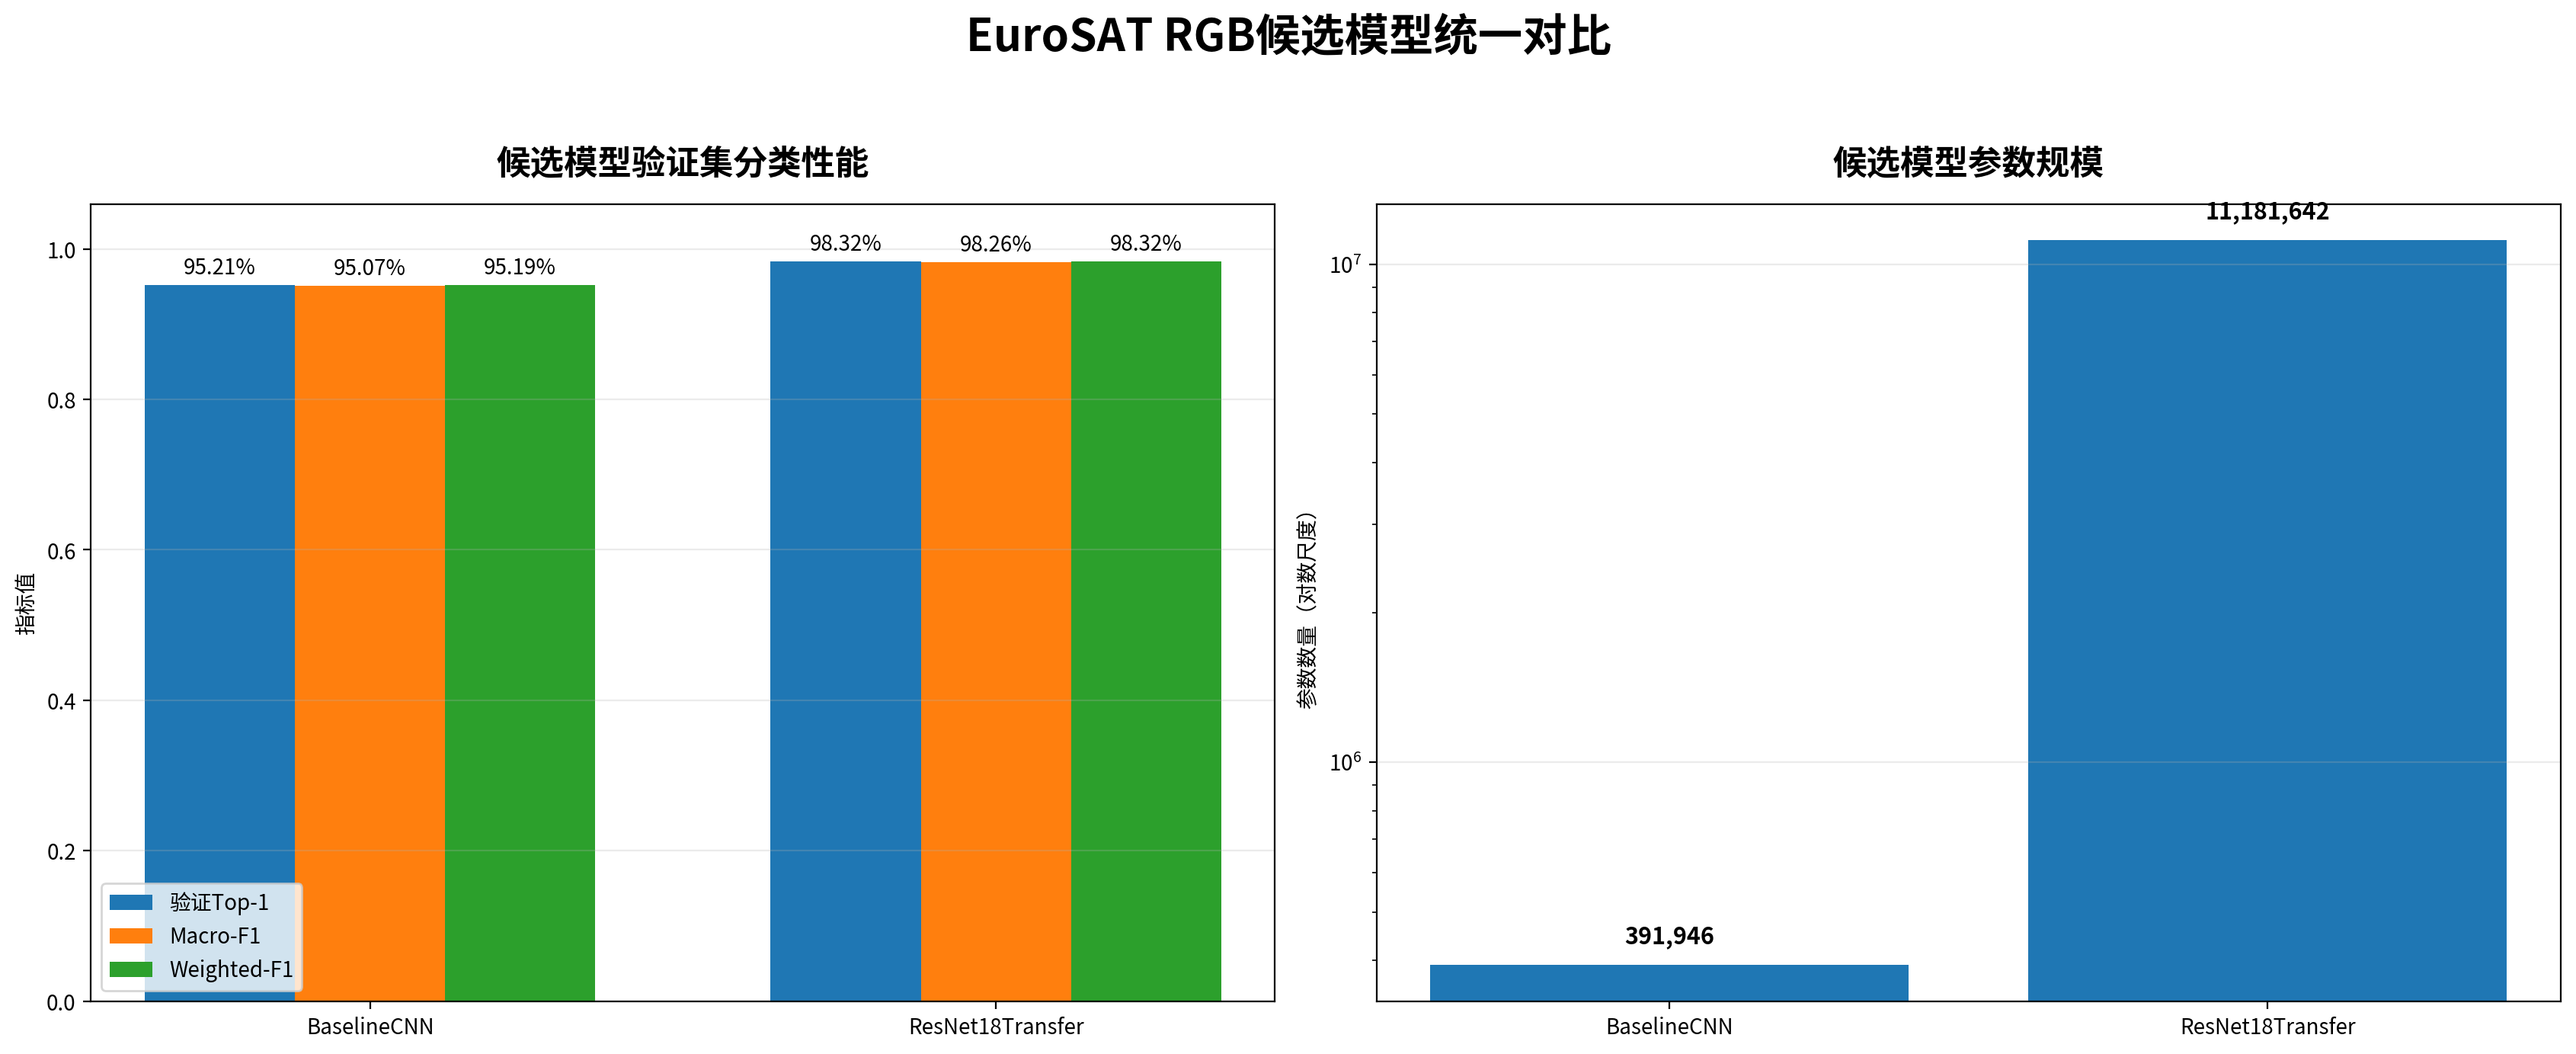


本图使用的候选模型数据：


,候选模型,验证Top-1,Macro-F1,Weighted-F1,模型总参数
0,BaselineCNN,0.952099,0.950705,0.951926,391946
1,ResNet18Transfer,0.983210,0.982560,0.983190,11181642



对比图已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定/05_候选模型性能与复杂度对比.png

Cell 6执行完成，可以继续运行下一个Cell。


In [9]:
# ==========================================
# Cell 6：候选模型性能与复杂度对比图
# 字段兼容与非交互式绘图修正版
# ==========================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import (
    Image as IPythonImage,
    display
)


# --------------------------------------------------
# 1. 检查必要变量
# --------------------------------------------------
required_variables = [
    "comparison_df",
    "OUTPUT_DIR"
]


missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]


if missing_variables:

    raise NameError(
        "当前内核缺少以下变量：\n"
        + "\n".join(
            missing_variables
        )
        + "\n\n请先运行修正后的Cell 4和Cell 5。"
    )


if len(
    comparison_df
) == 0:

    raise ValueError(
        "comparison_df为空，无法绘制候选模型对比图。"
    )


# --------------------------------------------------
# 2. 自动识别模型名称字段
# --------------------------------------------------
model_name_candidates = [
    "候选模型",
    "模型名称",
    "模型",
    "model_name"
]


model_name_column = next(
    (
        column_name
        for column_name in model_name_candidates
        if column_name in comparison_df.columns
    ),
    None
)


if model_name_column is None:

    raise KeyError(
        "候选模型对比表中未找到模型名称字段。\n"
        f"当前字段为：{comparison_df.columns.tolist()}"
    )


print(
    f"采用模型名称字段："
    f"{model_name_column}"
)


# --------------------------------------------------
# 3. 整理绘图数据
# --------------------------------------------------
plot_df = comparison_df.copy()


model_labels = (
    plot_df[
        model_name_column
    ]
    .astype(
        str
    )
    .tolist()
)


possible_metrics = [
    (
        "验证Top-1",
        "验证Top-1"
    ),
    (
        "Macro-F1",
        "Macro-F1"
    ),
    (
        "Weighted-F1",
        "Weighted-F1"
    )
]


metrics_to_plot = []


for column_name, display_name in possible_metrics:

    if column_name not in plot_df.columns:

        print(
            f"跳过不存在的指标："
            f"{column_name}"
        )

        continue


    plot_df[
        column_name
    ] = pd.to_numeric(
        plot_df[
            column_name
        ],
        errors="coerce"
    )


    if plot_df[
        column_name
    ].notna().sum() == 0:

        print(
            f"跳过全部为空的指标："
            f"{column_name}"
        )

        continue


    metrics_to_plot.append(
        (
            column_name,
            display_name
        )
    )


if len(
    metrics_to_plot
) == 0:

    raise ValueError(
        "没有可用于绘图的分类性能指标。"
    )


if "模型总参数" not in plot_df.columns:

    raise KeyError(
        "comparison_df中不存在“模型总参数”字段。"
    )


plot_df[
    "模型总参数"
] = pd.to_numeric(
    plot_df[
        "模型总参数"
    ],
    errors="coerce"
)


if plot_df[
    "模型总参数"
].isna().any():

    raise ValueError(
        "部分候选模型的参数量为空，"
        "无法绘制复杂度对比图。"
    )


# --------------------------------------------------
# 4. 设置非交互式绘图模式
# 避免VS Code远程输出渲染卡顿
# --------------------------------------------------
plt.close(
    "all"
)

plt.switch_backend(
    "Agg"
)


OUTPUT_DIR = Path(
    OUTPUT_DIR
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------------
# 5. 创建画布
# --------------------------------------------------
figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        17,
        7
    )
)


positions = np.arange(
    len(
        plot_df
    )
)


metric_count = len(
    metrics_to_plot
)


width = min(
    0.26,
    0.72 / metric_count
)


# --------------------------------------------------
# 6. 左图：验证集分类性能
# --------------------------------------------------
for metric_index, (
    column_name,
    display_name
) in enumerate(
    metrics_to_plot
):

    values = (
        plot_df[
            column_name
        ]
        .to_numpy(
            dtype=float
        )
    )


    horizontal_offset = (
        metric_index
        - (
            metric_count - 1
        )
        / 2
    ) * width


    bars = axes[
        0
    ].bar(
        positions
        + horizontal_offset,
        values,
        width=width,
        label=display_name
    )


    for bar, value in zip(
        bars,
        values
    ):

        if np.isfinite(
            value
        ):

            axes[
                0
            ].text(
                bar.get_x()
                + bar.get_width()
                / 2,
                min(
                    value + 0.008,
                    1.015
                ),
                f"{value:.2%}",
                ha="center",
                va="bottom",
                fontsize=10
            )

        else:

            axes[
                0
            ].text(
                bar.get_x()
                + bar.get_width()
                / 2,
                0.02,
                "缺失",
                ha="center",
                va="bottom",
                fontsize=9
            )


axes[
    0
].set_xticks(
    positions
)

axes[
    0
].set_xticklabels(
    model_labels
)

axes[
    0
].set_ylim(
    0,
    1.06
)

axes[
    0
].set_ylabel(
    "指标值"
)

axes[
    0
].set_title(
    "候选模型验证集分类性能",
    fontsize=16,
    fontweight="bold",
    pad=14
)

axes[
    0
].grid(
    axis="y",
    alpha=0.25
)

axes[
    0
].legend()


# --------------------------------------------------
# 7. 右图：参数规模
# --------------------------------------------------
parameter_values = (
    plot_df[
        "模型总参数"
    ]
    .to_numpy(
        dtype=float
    )
)


parameter_bars = axes[
    1
].bar(
    positions,
    parameter_values
)


axes[
    1
].set_xticks(
    positions
)

axes[
    1
].set_xticklabels(
    model_labels
)

axes[
    1
].set_yscale(
    "log"
)

axes[
    1
].set_ylabel(
    "参数数量（对数尺度）"
)

axes[
    1
].set_title(
    "候选模型参数规模",
    fontsize=16,
    fontweight="bold",
    pad=14
)

axes[
    1
].grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    parameter_bars,
    parameter_values
):

    axes[
        1
    ].text(
        bar.get_x()
        + bar.get_width()
        / 2,
        value * 1.08,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# --------------------------------------------------
# 8. 整体标题与保存
# --------------------------------------------------
figure.suptitle(
    "EuroSAT RGB候选模型统一对比",
    fontsize=21,
    fontweight="bold"
)


figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94
    ]
)


figure_path = (
    OUTPUT_DIR
    / "05_候选模型性能与复杂度对比.png"
)


figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)


plt.close(
    figure
)


# --------------------------------------------------
# 9. 静态显示，避免ipywidgets渲染
# --------------------------------------------------
display(
    IPythonImage(
        filename=str(
            figure_path
        )
    )
)


# --------------------------------------------------
# 10. 输出用于检查的数据
# --------------------------------------------------
display_columns = [
    model_name_column
]


for column_name, _ in metrics_to_plot:

    display_columns.append(
        column_name
    )


display_columns.append(
    "模型总参数"
)


print(
    "\n本图使用的候选模型数据："
)

display(
    plot_df[
        display_columns
    ]
)


print(
    f"\n对比图已保存：\n"
    f"{figure_path}"
)

print(
    "\nCell 6执行完成，可以继续运行下一个Cell。"
)

In [11]:
# ==========================================
# Cell 7：输出最终模型确定总结
# 字段兼容与结果检查修正版
# ==========================================

from pathlib import Path

import numpy as np
import pandas as pd


# --------------------------------------------------
# 1. 检查必要变量
# --------------------------------------------------
required_variables = [
    "comparison_df",
    "OUTPUT_DIR"
]


missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]


if missing_variables:

    raise NameError(
        "当前内核缺少以下变量：\n"
        + "\n".join(
            missing_variables
        )
        + "\n\n请先运行修正后的Cell 4、Cell 5和Cell 6。"
    )


if len(
    comparison_df
) == 0:

    raise ValueError(
        "comparison_df为空，无法生成候选模型比较总结。"
    )


# --------------------------------------------------
# 2. 自动识别模型名称字段
# --------------------------------------------------
model_name_candidates = [
    "候选模型",
    "模型名称",
    "模型",
    "model_name"
]


model_name_column = next(
    (
        column_name
        for column_name in model_name_candidates
        if column_name in comparison_df.columns
    ),
    None
)


if model_name_column is None:

    raise KeyError(
        "候选模型对比表中未找到模型名称字段。\n"
        f"当前字段为：{comparison_df.columns.tolist()}"
    )


print(
    f"采用模型名称字段：{model_name_column}"
)


# --------------------------------------------------
# 3. 检查总结所需指标
# --------------------------------------------------
required_columns = [
    model_name_column,
    "验证Top-1",
    "Macro-F1",
    "模型总参数"
]


missing_columns = [
    column_name
    for column_name in required_columns
    if column_name not in comparison_df.columns
]


if missing_columns:

    raise KeyError(
        "候选模型对比表缺少以下字段：\n"
        + "\n".join(
            missing_columns
        )
    )


summary_df = comparison_df.copy()


summary_df[
    model_name_column
] = (
    summary_df[
        model_name_column
    ]
    .astype(
        str
    )
    .str.strip()
)


for column_name in [
    "验证Top-1",
    "Macro-F1",
    "模型总参数"
]:

    summary_df[
        column_name
    ] = pd.to_numeric(
        summary_df[
            column_name
        ],
        errors="coerce"
    )


# --------------------------------------------------
# 4. 定位两个候选模型
# --------------------------------------------------
baseline_rows = summary_df.loc[
    summary_df[
        model_name_column
    ].str.lower() == "baselinecnn"
]


resnet_rows = summary_df.loc[
    summary_df[
        model_name_column
    ].str.lower() == "resnet18transfer"
]


if len(
    baseline_rows
) == 0:

    raise ValueError(
        "候选模型对比表中未找到BaselineCNN。\n"
        f"当前模型名称为："
        f"{summary_df[model_name_column].tolist()}"
    )


if len(
    resnet_rows
) == 0:

    raise ValueError(
        "候选模型对比表中未找到ResNet18Transfer。\n"
        f"当前模型名称为："
        f"{summary_df[model_name_column].tolist()}"
    )


baseline_row = baseline_rows.iloc[
    0
]


resnet_row = resnet_rows.iloc[
    0
]


# --------------------------------------------------
# 5. 检查关键数值是否完整
# --------------------------------------------------
for model_name, model_row in [
    (
        "BaselineCNN",
        baseline_row
    ),
    (
        "ResNet18Transfer",
        resnet_row
    )
]:

    for metric_name in [
        "验证Top-1",
        "Macro-F1",
        "模型总参数"
    ]:

        if pd.isna(
            model_row[
                metric_name
            ]
        ):

            raise ValueError(
                f"{model_name}的{metric_name}为空，"
                "无法生成最终比较总结。"
            )


# --------------------------------------------------
# 6. 计算模型间变化
# --------------------------------------------------
macro_f1_change = float(
    resnet_row[
        "Macro-F1"
    ]
    - baseline_row[
        "Macro-F1"
    ]
)


top1_change = float(
    resnet_row[
        "验证Top-1"
    ]
    - baseline_row[
        "验证Top-1"
    ]
)


baseline_parameters = float(
    baseline_row[
        "模型总参数"
    ]
)


resnet_parameters = float(
    resnet_row[
        "模型总参数"
    ]
)


if baseline_parameters <= 0:

    raise ValueError(
        "BaselineCNN参数量必须大于0。"
    )


parameter_ratio = float(
    resnet_parameters
    / baseline_parameters
)


# --------------------------------------------------
# 7. 恢复或确定最终模型名称
# --------------------------------------------------
if (
    "selected_model_name"
    in globals()
    and str(
        selected_model_name
    ).strip()
):

    final_model_name = str(
        selected_model_name
    ).strip()


elif (
    "final_selection"
    in globals()
    and isinstance(
        final_selection,
        dict
    )
    and final_selection.get(
        "最终模型名称"
    )
):

    final_model_name = str(
        final_selection[
            "最终模型名称"
        ]
    ).strip()


elif "ranked_df" in globals():

    possible_rank_name_column = next(
        (
            column_name
            for column_name in [
                "候选模型",
                "模型名称"
            ]
            if column_name in ranked_df.columns
        ),
        None
    )


    if possible_rank_name_column is None:

        final_model_name = str(
            summary_df.sort_values(
                by=[
                    "Macro-F1",
                    "验证Top-1",
                    "模型总参数"
                ],
                ascending=[
                    False,
                    False,
                    True
                ]
            ).iloc[
                0
            ][
                model_name_column
            ]
        )

    else:

        final_model_name = str(
            ranked_df.iloc[
                0
            ][
                possible_rank_name_column
            ]
        )


else:

    final_model_name = str(
        summary_df.sort_values(
            by=[
                "Macro-F1",
                "验证Top-1",
                "模型总参数"
            ],
            ascending=[
                False,
                False,
                True
            ]
        ).iloc[
            0
        ][
            model_name_column
        ]
    )


# --------------------------------------------------
# 8. 生成文字总结
# --------------------------------------------------
summary_text = f"""
EuroSAT RGB候选模型比较与最终模型确定
============================================================

一、BaselineCNN验证结果
验证Top-1：{baseline_row['验证Top-1']:.4%}
验证Macro-F1：{baseline_row['Macro-F1']:.4%}
模型参数量：{int(baseline_row['模型总参数']):,}

二、ResNet18Transfer验证结果
验证Top-1：{resnet_row['验证Top-1']:.4%}
验证Macro-F1：{resnet_row['Macro-F1']:.4%}
模型参数量：{int(resnet_row['模型总参数']):,}

三、模型差异
ResNet18Transfer相对BaselineCNN的Top-1变化：{top1_change:+.4%}
ResNet18Transfer相对BaselineCNN的Macro-F1变化：{macro_f1_change:+.4%}
ResNet18Transfer参数量约为BaselineCNN的：{parameter_ratio:.2f}倍

四、最终模型确定
最终选择：{final_model_name}

选择规则：
首先比较统一验证集Macro-F1；当Macro-F1相同时，比较验证集Top-1；
若分类性能仍相同，则优先选择模型参数量更少的候选模型。

选择结论：
ResNet18Transfer利用ImageNet预训练特征和残差结构获得了更强的遥感场景
特征表达能力。虽然其参数规模明显高于BaselineCNN，但验证集分类性能更优，
因此将其确定为后续测试集正式评估和可解释性分析的最终候选模型。

测试集状态：尚未用于模型训练、调参或候选模型选择。

下一步：
在6.3.1中加载最终模型，对完全隔离的测试集进行一次正式性能评估。
""".strip()


# --------------------------------------------------
# 9. 保存总结文件
# --------------------------------------------------
OUTPUT_DIR = Path(
    OUTPUT_DIR
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


summary_path = (
    OUTPUT_DIR
    / "06_候选模型比较与最终选择总结.txt"
)


summary_path.write_text(
    summary_text,
    encoding="utf-8"
)


# 同时保存核心差异数据，便于课程报告引用
difference_summary_df = pd.DataFrame([
    {
        "比较项目": "验证Top-1变化",
        "数值": top1_change,
        "显示值": f"{top1_change:+.4%}"
    },
    {
        "比较项目": "验证Macro-F1变化",
        "数值": macro_f1_change,
        "显示值": f"{macro_f1_change:+.4%}"
    },
    {
        "比较项目": "参数量倍数",
        "数值": parameter_ratio,
        "显示值": f"{parameter_ratio:.2f}倍"
    }
])


difference_summary_path = (
    OUTPUT_DIR
    / "07_候选模型核心差异.csv"
)


difference_summary_df.to_csv(
    difference_summary_path,
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------------
# 10. 输出结果
# --------------------------------------------------
print(
    summary_text
)


print(
    f"\n总结文件已保存：\n"
    f"{summary_path}"
)


print(
    f"\n模型差异数据已保存：\n"
    f"{difference_summary_path}"
)


print(
    "\n6.2.4候选模型比较与最终模型确定已完成。"
)

print(
    "下一步可以运行："
    "6.3.1_最终模型测试集性能评估.ipynb"
)

采用模型名称字段：候选模型
EuroSAT RGB候选模型比较与最终模型确定

一、BaselineCNN验证结果
验证Top-1：95.2099%
验证Macro-F1：95.0705%
模型参数量：391,946

二、ResNet18Transfer验证结果
验证Top-1：98.3210%
验证Macro-F1：98.2560%
模型参数量：11,181,642

三、模型差异
ResNet18Transfer相对BaselineCNN的Top-1变化：+3.1111%
ResNet18Transfer相对BaselineCNN的Macro-F1变化：+3.1855%
ResNet18Transfer参数量约为BaselineCNN的：28.53倍

四、最终模型确定
最终选择：ResNet18Transfer

选择规则：
首先比较统一验证集Macro-F1；当Macro-F1相同时，比较验证集Top-1；
若分类性能仍相同，则优先选择模型参数量更少的候选模型。

选择结论：
ResNet18Transfer利用ImageNet预训练特征和残差结构获得了更强的遥感场景
特征表达能力。虽然其参数规模明显高于BaselineCNN，但验证集分类性能更优，
因此将其确定为后续测试集正式评估和可解释性分析的最终候选模型。

测试集状态：尚未用于模型训练、调参或候选模型选择。

下一步：
在6.3.1中加载最终模型，对完全隔离的测试集进行一次正式性能评估。

总结文件已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定/06_候选模型比较与最终选择总结.txt

模型差异数据已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.4_候选模型训练结果对比与最终模型确定/07_候选模型核心差异.csv

6.2.4候选模型比较与最终模型确定已完成。
下一步可以运行：6.3.1_最终模型测试集性能评估.ipynb
